In [21]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit.library import RealAmplitudes, EfficientSU2
from qiskit.quantum_info import Statevector, state_fidelity, partial_trace
from scipy.special import rel_entr
import matplotlib.pyplot as plt
from tqdm import tqdm
import numba as nb

## Expressibility

In [35]:
def compute_fidelity(circuit1: QuantumCircuit, circuit2: QuantumCircuit) -> float:
    """
    Compute the fidelity between the states produced by two quantum circuits.
    """
    sv1 = Statevector.from_instruction(circuit1)
    sv2 = Statevector.from_instruction(circuit2)
    return state_fidelity(sv1, sv2)


def prob_haar(l: float, u: float, n: int) -> float:
    """
    Compute the probability of measuring a fidelity in the interval [l, u] of a histogram bin for Haar random states.

    Args:
        l: lower bound of the interval (for a histogram bin)
        u: upper bound of the interval
        n: number of qubits
    """
    N = 2**n
    return (1 - l) ** (N - 1) - (1 - u) ** (N - 1)


def generate_random_params(num_params: int) -> np.ndarray:
    """
    Generate random parameters for a parameterized quantum circuit.

    Args:
        num_params: number of parameters
    """
    return np.random.uniform(0, 4 * np.pi, num_params)


def generate_fidelity_dists(
    ansatz: QuantumCircuit, num_samples: int, num_bins: int
) -> tuple[np.ndarray, np.ndarray]:
    """
    Generate fidelity distributions for Haar random states and for a given parameterized ansatz.

    Args:
        ansatz: parameterized ansatz circuit
        num_samples: number of samples to draw from the Haar measure
        num_bins: number of bins for the histogram

    Returns:
        A tuple containing the fidelity distributions for Haar random states and one for the parameterized ansatz.
    """
    num_qubits = ansatz.num_qubits
    bins_list = np.linspace(0, 1, num_bins + 1)
    haar_fidelities_hist = []
    for i in range(num_bins):
        haar_fidelities_hist.append(
            prob_haar(bins_list[i], bins_list[i + 1], num_qubits)
        )

    haar_fidelities_hist = np.array(haar_fidelities_hist)

    ansatz_fidelities = []
    for _ in tqdm(range(num_samples)):
        params_1 = generate_random_params(ansatz.num_parameters)
        circ_1 = ansatz.assign_parameters(params_1)
        params_2 = generate_random_params(ansatz.num_parameters)
        circ_2 = ansatz.assign_parameters(params_2)
        ansatz_fidelities.append(compute_fidelity(circ_1, circ_2))

    weights = np.ones_like(ansatz_fidelities) / len(ansatz_fidelities)
    ansatz_fidelities_hist = np.histogram(
        ansatz_fidelities, bins=bins_list, weights=weights
    )[0]

    return haar_fidelities_hist, ansatz_fidelities_hist


def compute_kl_divergence(
    haar_fidelities: np.ndarray, ansatz_fidelities: np.ndarray
) -> float:
    """
    Compute the Kullback-Leibler divergence between two fidelity distributions.

    Args:
        haar_fidelities: fidelity distribution for Haar random states
        ansatz_fidelities: fidelity distribution for the parameterized ansatz
    """
    # Find indices where both distributions contain zero and remove them (to avoid infinity in KL divergence)
    atol = 1e-32
    indices = np.logical_and(
        np.isclose(haar_fidelities, 0), np.isclose(ansatz_fidelities, 0)
    )
    haar_fidelities = haar_fidelities[~indices]
    ansatz_fidelities = ansatz_fidelities[~indices]
    # Check which distribution still has zero values
    if np.isclose(haar_fidelities, 0, atol=atol).any():
        kl_divergence = sum(rel_entr(haar_fidelities, ansatz_fidelities))
    elif np.isclose(ansatz_fidelities, 0, atol=atol).any():
        kl_divergence = sum(rel_entr(ansatz_fidelities, haar_fidelities))
    else:
        kl_divergence = sum(rel_entr(haar_fidelities, ansatz_fidelities))
    return kl_divergence


def plot_histogram(
    haar_fidelities: list, ansatz_fidelities: list, title: str | None = None
) -> None:
    """
    Plot the histogram of fidelity distributions for Haar random states and for the parameterized ansatz.

    Args:
        haar_fidelities: fidelity distribution for Haar random states
        ansatz_fidelities: fidelity distribution for the parameterized ansatz
    """
    num_bins = len(haar_fidelities)
    bins_list = np.linspace(0, 1, num_bins + 1)
    bins_center = [(bins_list[i] + bins_list[i + 1]) / 2 for i in range(num_bins)]

    plt.bar(
        bins_center, ansatz_fidelities, width=1 / num_bins, alpha=0.5, label="Ansatz"
    )
    plt.plot(bins_center, haar_fidelities, label="Haar", color="orange")
    plt.xlabel("Fidelity")
    plt.ylabel("Probability")
    if title:
        plt.title(title)
    plt.legend()
    plt.show()


# def compute_fidelity_alt(circuit1: QuantumCircuit, circuit2: QuantumCircuit) -> float:
#     """
#     Compute the fidelity between the states produced by two quantum circuits.
#     """
#     circ = circuit1.compose(circuit2.inverse())
#     sv = Statevector.from_instruction(circ)
#     return sv.probabilities()[0]

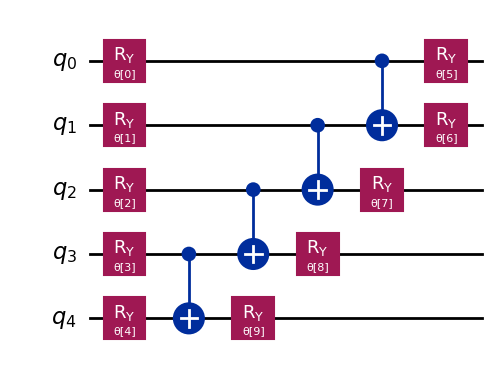

In [5]:
RealAmplitudes(num_qubits=5, reps=1).decompose().draw('mpl')

100%|██████████| 5000/5000 [00:03<00:00, 1439.16it/s]


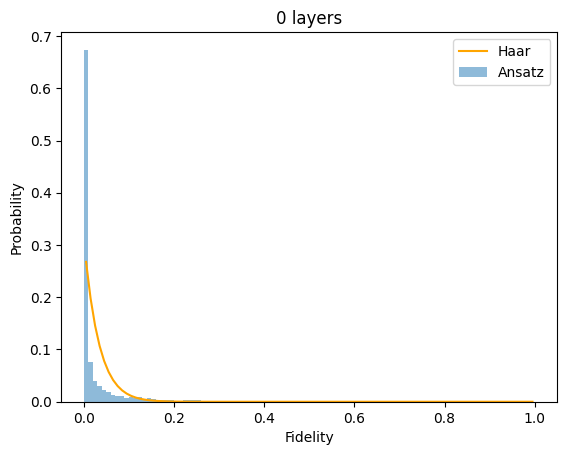

100%|██████████| 5000/5000 [00:06<00:00, 794.22it/s]


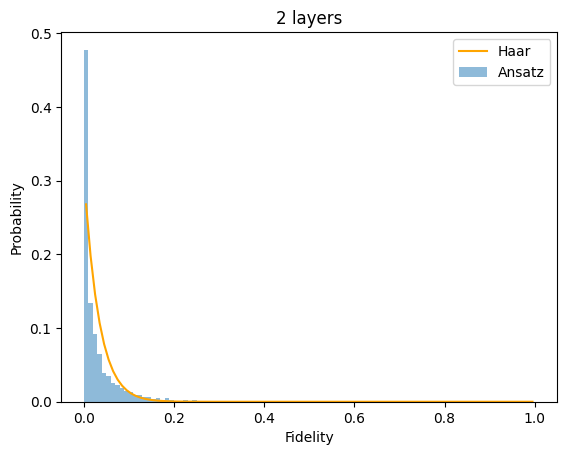

100%|██████████| 5000/5000 [00:09<00:00, 545.39it/s]


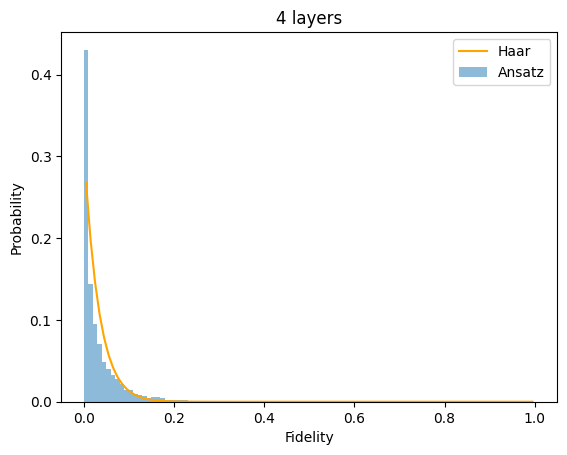

100%|██████████| 5000/5000 [00:11<00:00, 426.43it/s]


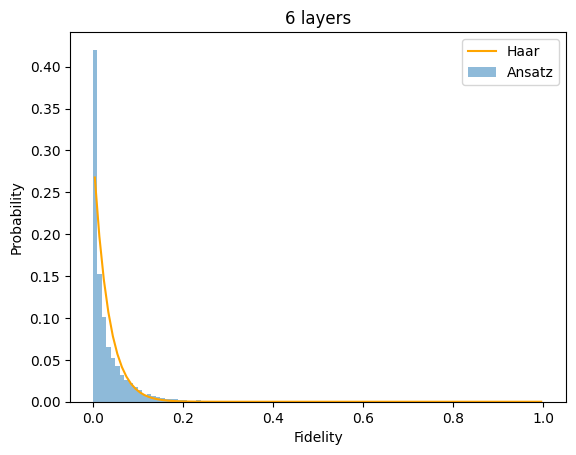

100%|██████████| 5000/5000 [00:15<00:00, 332.86it/s]


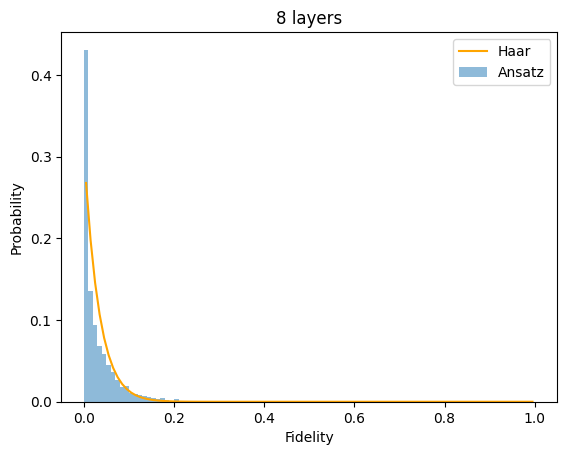

100%|██████████| 5000/5000 [00:18<00:00, 273.02it/s]


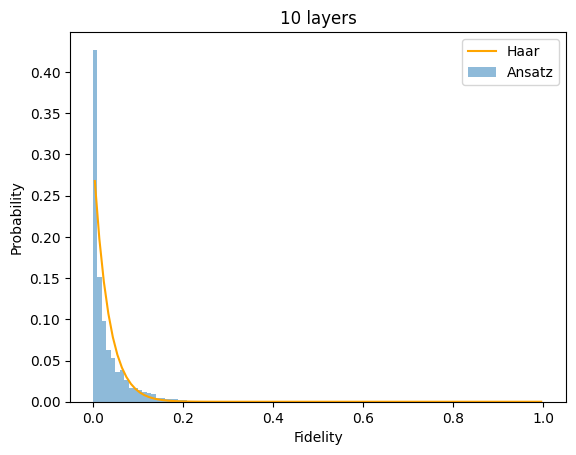

In [6]:
num_layers_list = [i for i in range(0, 11)]
# num_layers_list = [3]
kl_divergences = []

for num_layers in num_layers_list:
    ansatz = RealAmplitudes(num_qubits=5, reps=num_layers)
    num_samples = 5000
    num_bins = 100
    haar_fidelities_hist, ansatz_fidelities_hist = generate_fidelity_dists(ansatz, num_samples, num_bins)
    kl_divergence = compute_kl_divergence(haar_fidelities_hist, ansatz_fidelities_hist)
    kl_divergences.append(kl_divergence)
    if num_layers % 2 == 0:
        plot_histogram(haar_fidelities_hist, ansatz_fidelities_hist, title=f"{num_layers} layers")

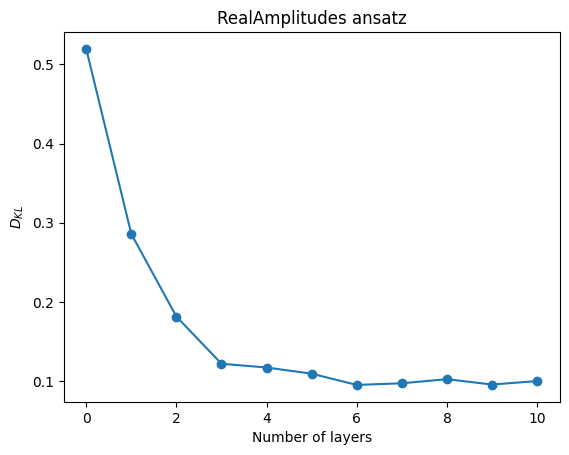

In [8]:
# Plot the KL divergence as a function of the number of layers
plt.plot(num_layers_list, kl_divergences, marker="o")
plt.xlabel("Number of layers")
plt.ylabel("$D_{KL}$")
plt.title("RealAmplitudes ansatz")
plt.show()

## Entangling capability

In [ ]:
def iota_j(statevector: np.ndarray, j: int) -> tuple[np.ndarray, np.ndarray]:
    """
    Compute the states ι_j(0)|ψ⟩ and ι_j(1)|ψ⟩ for the j-th qubit, where ι_j(b)|b_1, ..., b_j, ..., b_n⟩ = δ_{bb_j} |b_1, ..., b_{j-1}, b_{j+1}, ..., b_n⟩.

    Args:
        statevector: full statevector of the quantum state
        j: index of the qubit to remove

    Returns:
        A tuple containing the states ι_j(0)|ψ⟩ and ι_j(1)|ψ⟩.
    """
    n = int(np.log2(len(statevector)))  # Number of qubits
    size = 2 ** (n - 1)  # New size after removing 1 qubit
    zero_state = np.zeros(size, dtype=np.complex64)
    one_state = np.zeros(size, dtype=np.complex64)

    # Iterate over all computational basis states
    for idx in range(2**n):
        # Binary representation of the state index
        bin_rep = np.binary_repr(idx, n)
        # If the j-th qubit is 0, add to zero_state
        if bin_rep[j] == "0":
            # Remove the j-th qubit and store the remaining qubits' state
            remaining_idx = int(bin_rep[:j] + bin_rep[j + 1 :], 2)
            zero_state[remaining_idx] = statevector[idx]
        # If the j-th qubit is 1, add to one_state
        else:
            remaining_idx = int(bin_rep[:j] + bin_rep[j + 1 :], 2)
            one_state[remaining_idx] = statevector[idx]

    return zero_state, one_state


@nb.njit
def generalized_distance(u: np.ndarray, v: np.ndarray) -> float:
    """
    Compute the generalized distance (wedge product) between two vectors.

    Args:
        u: statevector of the first quantum state
        v: statevector of the second quantum state

    Returns:
        The generalized distance between the two states.
    """
    distance = 0
    for i in range(len(u)):
        for j in range(i + 1, len(v)):
            distance += np.abs(u[i] * v[j] - u[j] * v[i]) ** 2
    return distance


def meyer_wallach_entanglement(statevector: np.ndarray) -> float:
    """
    Compute the Meyer-Wallach entanglement measure Q(|ψ⟩) for a given quantum state.

    Args:
        statevector: full statevector of the quantum state

    Returns:
        The Meyer-Wallach entanglement measure.
    """
    num_qubits = int(np.log2(len(statevector)))  # Number of qubits
    entanglement = 0
    for j in range(num_qubits):
        zero_state, one_state = iota_j(statevector, j)
        entanglement += generalized_distance(zero_state, one_state)
    Q = 4 / num_qubits * entanglement
    return Q

In [44]:
def meyer_wallach_entanglement_alt(statevector: np.ndarray) -> float:
    """
    Compute the Meyer-Wallach entanglement measure Q(|ψ⟩) for a given quantum state, as the average linear purity (i.e., tr{ρ^2}) of all the single qubit reduced states.
    cf. G. K. Brennen, Quantum Inf. Comput. 2003, 3, 619.
    Note: This is much faster than the generalized distance implementation.

    Args:
        statevector: full statevector of the quantum state

    Returns:
        The Meyer-Wallach entanglement measure.
    """
    num_qubits = int(np.log2(len(statevector)))  # Number of qubits
    entanglement = 0
    for k in range(num_qubits):
        traced_qubits = [i for i in range(num_qubits) if i != k]
        reduced_state = partial_trace(statevector, traced_qubits).data
        entanglement += np.real(np.trace(reduced_state @ reduced_state))
    Q = 2 * (1 - (1 / num_qubits) * entanglement)
    return Q


def sample_entanglement(ansatz: QuantumCircuit, num_samples: int) -> np.ndarray:
    """
    Sample the Meyer-Wallach entanglement values for a given parameterized ansatz.

    Args:
        ansatz: parameterized ansatz circuit
        num_samples: number of samples to draw

    Returns:
        The entanglement values for different parameter realizations of the quantum circuit.
    """
    entanglement_values = []
    for _ in tqdm(range(num_samples)):
        params = generate_random_params(ansatz.num_parameters)
        circ = ansatz.assign_parameters(params)
        statevector = Statevector.from_instruction(circ)
        entanglement = meyer_wallach_entanglement_alt(statevector.data)
        entanglement_values.append(entanglement)
    return entanglement_values


def compute_entangling_capability(entanglement_values: np.ndarray) -> float:
    """
    Compute the entangling capability of a quantum circuit, defined as the average entanglement.

    Args:
        entanglement_dist: a list of entanglement values for different parameter realizations of the quantum circuit
    """
    return np.mean(entanglement_values)
    


def plot_entanglement_dist(entanglement_values: np.ndarray, num_bins: int = 100, title: str | None = None) -> None:
    """
    Plot the entanglement distribution of a quantum circuit.

    Args:
        entanglement_dist: entanglement distribution of the quantum circuit
    """
    weights = np.ones_like(entanglement_values) / len(entanglement_values)
    entanglement_hist = np.histogram(entanglement_values, bins=num_bins, weights=weights)[0]
    bins_list = np.linspace(0, 1, num_bins + 1)
    bins_center = [(bins_list[i] + bins_list[i + 1]) / 2 for i in range(num_bins)]

    plt.bar(bins_center, entanglement_hist, width=1 / num_bins, alpha=0.5)
    plt.xlabel("Entanglement")
    plt.ylabel("Probability")
    if title:
        plt.title(title)
    plt.show()

100%|██████████| 5000/5000 [00:02<00:00, 2347.10it/s]


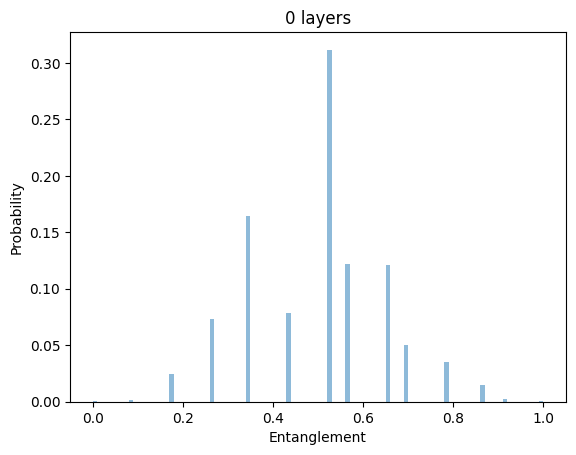

100%|██████████| 5000/5000 [00:03<00:00, 1460.40it/s]


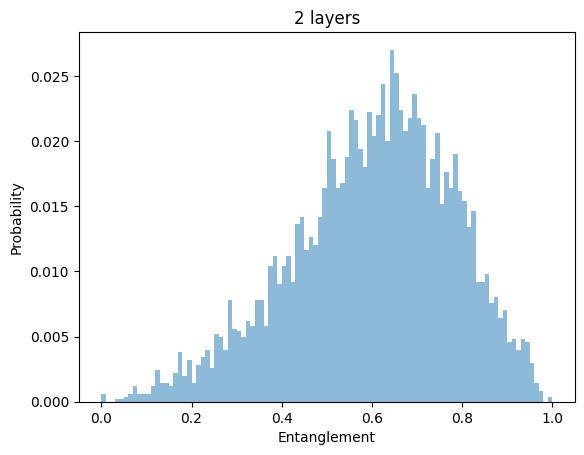

100%|██████████| 5000/5000 [00:04<00:00, 1015.92it/s]


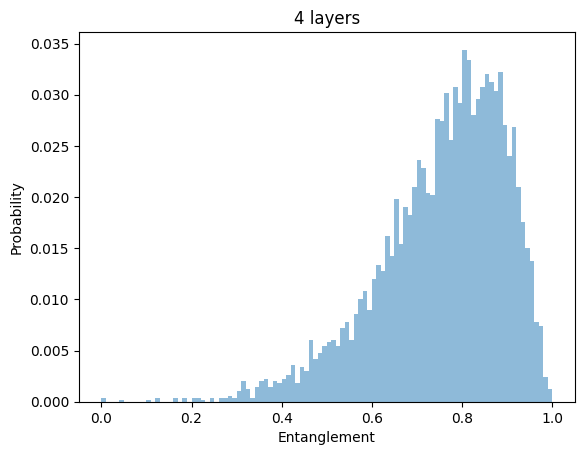

100%|██████████| 5000/5000 [00:06<00:00, 735.88it/s]


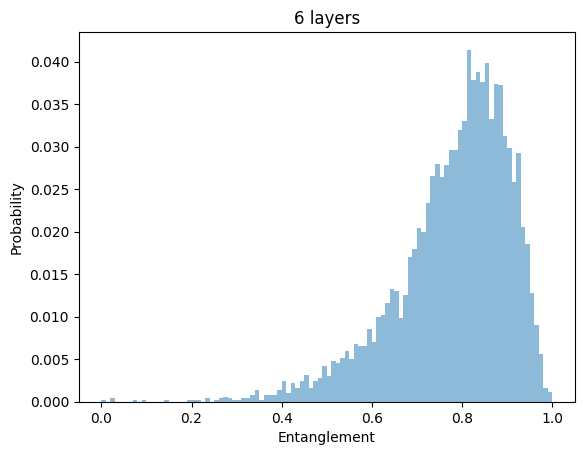

100%|██████████| 5000/5000 [00:08<00:00, 564.33it/s]


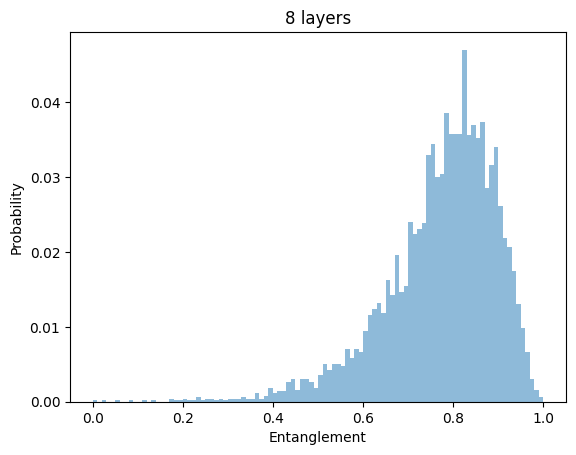

100%|██████████| 5000/5000 [00:08<00:00, 556.36it/s]


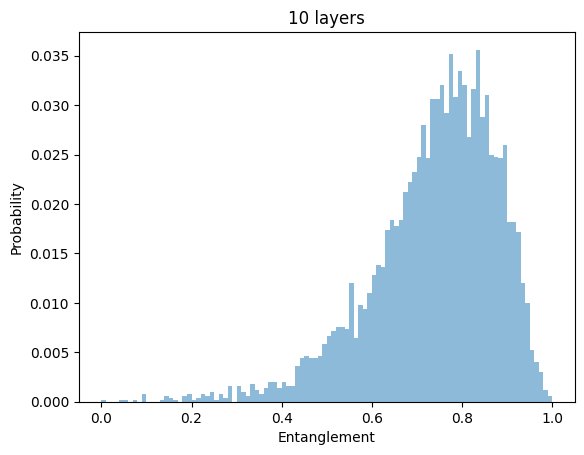

In [48]:
num_layers_list = [i for i in range(0, 11)]
# num_layers_list = [2]
num_samples = 5000
num_bins = 100
entangling_capabilities = []

for num_layers in num_layers_list:
    ansatz = RealAmplitudes(num_qubits=5, reps=num_layers)
    entanglement_values = sample_entanglement(ansatz, num_samples)
    entangling_capability_value = compute_entangling_capability(entanglement_values)
    # print(f"Entangling capability for {num_layers} layers: {entangling_capability_value}")
    entangling_capabilities.append(entangling_capability_value)
    if num_layers % 2 == 0:
        plot_entanglement_dist(entanglement_values, num_bins=num_bins, title=f"{num_layers} layers")

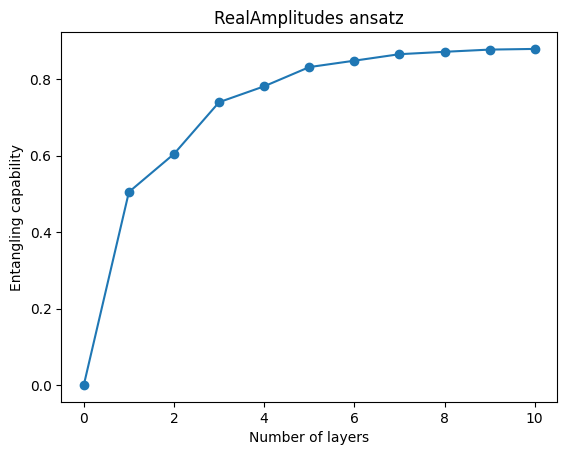

In [49]:
# Plot the entangling capability as a function of the number of layers
plt.plot(num_layers_list, entangling_capabilities, marker="o")
plt.xlabel("Number of layers")
plt.ylabel("Entangling capability")
plt.title("RealAmplitudes ansatz")
plt.show()